In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 
import cartopy.feature as cfeature

In [2]:
foccus = '/lustre/storeB/project/fou/hi/foccus'
filepath = 'malene/run-anemoi-ocean/ppi/external_checkpoint_inference/Inference_res/2024-04-02_.ckpt_e010_s020000.nc' #inference results from my own run

#inference results 

In [3]:
ds = xr.open_dataset(f'{foccus}/{filepath}')

In [120]:
ds.longitude.max()

<xarray.DataArray 'longitude' ()> Size: 4B
array(37.55454, dtype=float32)

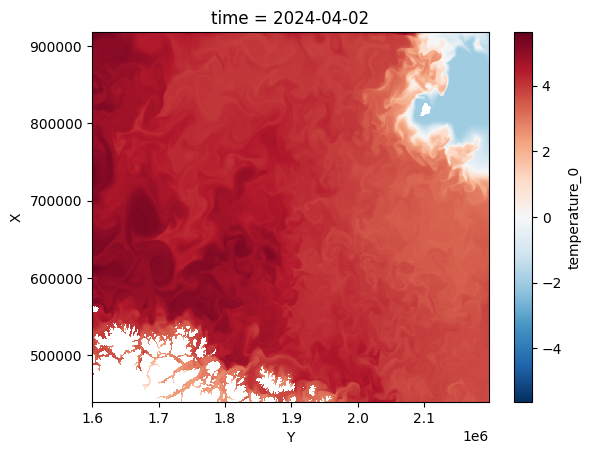

In [114]:
ds['temperature_0'][0,550:, 2000:].plot() #finding an ocean area 
ocean = ds.sel(X = slice(550,1148), Y = slice(2000,2747))

In [4]:
#okay so plotting f / h seems simple enough, because we already have them both - but do we need to interpolate?? maybe not ..

f = ds.f
h = ds.h 

In [5]:
#then cut out an area - it is of interst to study either Vestlandet or Lofoten as discussed with Matheusz
#We expect the bottom topography to impact the surface currents. We should see that f/h follows the ocean currents u and v

import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 11.83, 11.83
lon_lrc, lon_urc = 15.59, 15.59
lat_urc, lat_ulc = 69.21, 69.21
lat_llc, lat_lrc = 67.41, 67.41

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

Lofoten = ds.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 572, X max: 862
Y min: 1680, Y max: 1986


In [6]:
Lofoten

<xarray.Dataset> Size: 147MB
Dimensions:            (X: 291, Y: 307, time: 17)
Coordinates:
  * X                  (X) float64 2kB 4.576e+05 4.584e+05 ... 6.896e+05
  * Y                  (Y) float64 2kB 1.344e+06 1.345e+06 ... 1.589e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 357kB 66.75 66.76 66.77 ... 69.83 69.83
    longitude          (X, Y) float32 357kB 14.4 14.42 14.43 ... 12.96 12.97
    h                  (time, X, Y) float32 6MB ...
    salinity_0         (time, X, Y) float32 6MB ...
    sea_mask           (time, X, Y) float32 6MB ...
    temperature_0      (time, X, Y) float32 6MB ...
    ...                 ...
    rain               (time, X, Y) float32 6MB ...
    river_binary_mask  (time, X, Y) float32 6MB ...
    sin_julian_day     (time, X, Y) float32 6MB ...
    sin_latitude       (time, X, Y) float32 6MB ...
    sin_local_time     (time, X, Y) float32 6MB ...
    sin_longitude      (time, X, Y) float32 6MB ...

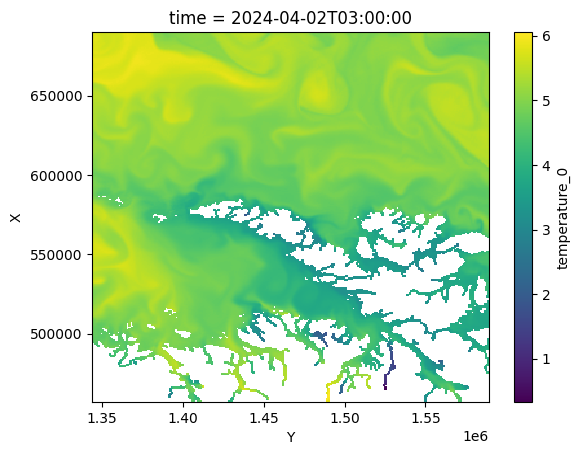

In [7]:
#just a quick check that it works
Lofoten.temperature_0.isel(time = 1).plot()

In [8]:
h_L = Lofoten.h 
f_L = Lofoten.f
zeta = Lofoten.zeta


In [9]:
print(h_L.shape)
print(zeta.shape)

(17, 291, 307)
(17, 291, 307)


In [10]:
f_h = f_L.values/h_L.values
f_h[0,slice(x_min,x_max),slice(y_min, y_max)]
np.printoptions(np.inf)
print(f_h)


[[[1.34002939e-05 1.34009051e-05 1.34015163e-05 ... 1.35760756e-05
   1.35766195e-05 1.35771643e-05]
  [1.34007114e-05 1.34013226e-05 1.34019338e-05 ... 1.35764985e-05
   1.35770433e-05 1.35775872e-05]
  [1.34011307e-05 1.34017419e-05 1.34023530e-05 ... 1.35769224e-05
   1.35774662e-05 1.35780110e-05]
  ...
  [1.39596850e-07 1.38451668e-07 1.37171170e-07 ... 4.86375349e-08
   4.86765153e-08 4.87209455e-08]
  [1.35197908e-07 1.33986475e-07 1.32607354e-07 ... 4.86511027e-08
   4.86866512e-08 4.87276957e-08]
  [1.31198746e-07 1.29997176e-07 1.28599993e-07 ... 4.86762630e-08
   4.87084257e-08 4.87458962e-08]]

 [[           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  [           nan            nan            nan ...            nan
              nan            nan]
  ...
  [           nan            nan            nan ...            nan
          

In [11]:
step = 5
min_l = -0.5e-5 
max_l = 1.44e-5
custom = np.linspace(min_l, max_l, 20)

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


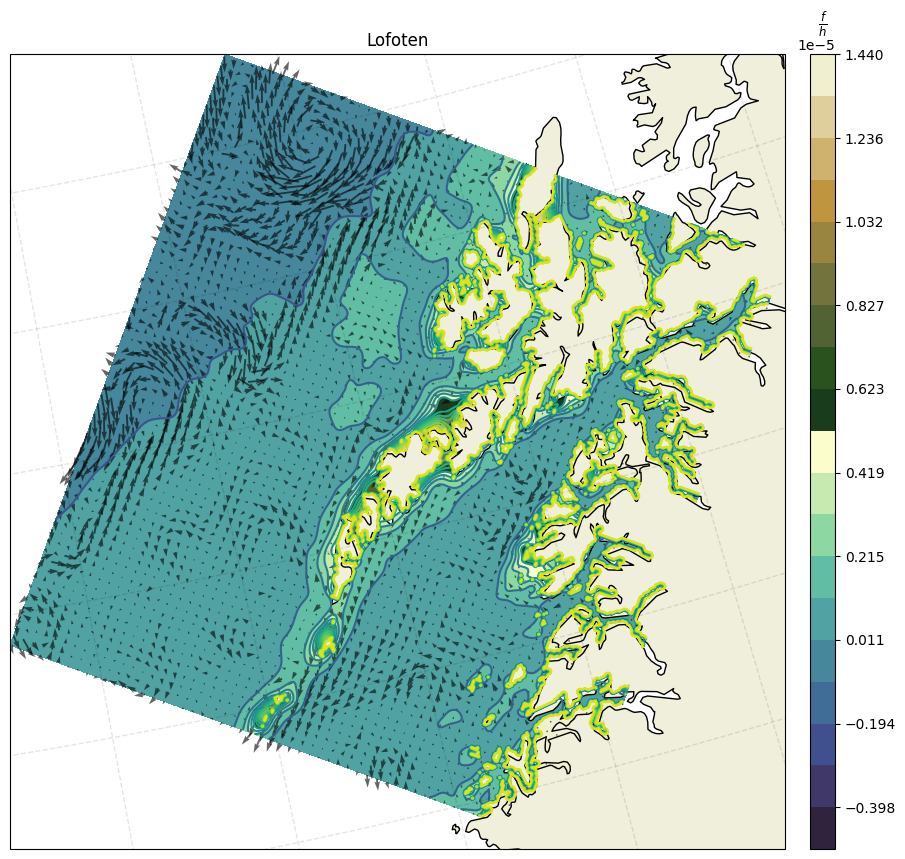

In [12]:
fig,ax = plt.subplots(figsize = (10,12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im = ax.contour(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
im2 = ax.contourf(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
ax.quiver(Lofoten.longitude.values[::step, ::step], Lofoten.latitude.values[::step, ::step], Lofoten.u_eastward_0[1,:,:].values[::step, ::step], Lofoten.v_northward_0[1,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
cbar = fig.colorbar(im2, ax=ax, cax = cax, extend = "both")
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
gl.xlabels_top = False
ax.set_title('Lofoten')
cbar.ax.set_title(r'$\frac{f}{h}$')
ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')

In [13]:
#Now do an average of the ocean velocities to find the avg flow and compare to f/h 
#Maybe just use xarray ?? :) or too easy of an fix 
mean_u_vel = Lofoten['u_eastward_0'].resample(time = 'D').mean(dim = 'time')
mean_v_vel = Lofoten['v_northward_0'].resample(time = 'D').mean(dim = 'time')

In [14]:
mean_v_vel

<xarray.DataArray 'v_northward_0' (time: 3, X: 291, Y: 307)> Size: 1MB
array([[[-1.3644674e-03, -2.7205232e-03, -2.2620484e-03, ...,
         -6.1427607e-05, -8.5541164e-04, -9.4639091e-04],
        [-1.1884118e-03, -5.0005381e-04, -1.2858106e-03, ...,
         -1.4469611e-04, -1.1319281e-03, -1.5616999e-04],
        [-3.6277334e-04, -4.9098732e-04, -1.1236269e-03, ...,
          2.2962486e-04, -8.1416476e-04,  1.6653705e-04],
        ...,
        [-1.6934130e-01, -1.8089738e-01, -2.1113215e-01, ...,
         -2.5203842e-01, -2.4757648e-01, -2.2225140e-01],
        [-1.5472022e-01, -1.5343682e-01, -1.8049282e-01, ...,
         -2.8541958e-01, -2.8653765e-01, -2.9039848e-01],
        [-1.1915988e-01, -1.6291660e-01, -1.9505006e-01, ...,
         -3.6555609e-01, -3.5047513e-01, -3.1297901e-01]],

       [[-6.7119529e-03, -1.0363002e-02, -9.2034414e-03, ...,
          1.2962885e-03, -2.0003628e-03, -3.2806396e-03],
        [-5.5712159e-03, -3.1111510e-03, -7.3508359e-03, ...,
          1.2270762e-03, -2.3203399e-03,  1.9845566e-04],
        [-2.7209951e-03, -3.6470655e-03, -4.8611942e-03, ...,
         -3.7330639e-04, -2.5961923e-03,  2.1346551e-03],
...
         -1.5241550e-01, -1.7701493e-01, -1.4692028e-01],
        [-7.0945486e-02, -1.1227616e-02, -1.9323330e-02, ...,
         -1.4821610e-01, -1.3751876e-01, -1.3212378e-01],
        [-2.1066938e-02, -2.0414617e-02, -6.9310114e-02, ...,
         -1.9640107e-01, -1.7656474e-01, -1.3138707e-01]],

       [[-9.1153393e-03, -1.4193059e-02, -1.2638369e-02, ...,
          2.9036992e-03, -1.9934271e-03, -4.1937525e-03],
        [-7.9121329e-03, -4.8103160e-03, -1.0698216e-02, ...,
          3.0701256e-03, -2.3940899e-03,  9.6278079e-04],
        [-3.5310746e-03, -5.8748396e-03, -6.6454886e-03, ...,
         -6.7620166e-04, -2.7808810e-03,  3.8546280e-03],
        ...,
        [-8.5396633e-02,  4.4227097e-02,  1.1196644e-02, ...,
          5.4933984e-02,  5.1575720e-02,  6.9760576e-02],
        [-3.2005954e-01, -2.3162970e-01, -1.8067698e-01, ...,
          1.5250391e-01,  1.7801058e-01,  1.8884569e-01],
        [-3.8646442e-01, -3.7432727e-01, -3.9738205e-01, ...,
          1.6400959e-01,  1.7243671e-01,  1.9962926e-01]]],
      shape=(3, 291, 307), dtype=float32)
Coordinates:
  * X        (X) float64 2kB 4.576e+05 4.584e+05 ... 6.888e+05 6.896e+05
  * Y        (Y) float64 2kB 1.344e+06 1.345e+06 ... 1.588e+06 1.589e+06
  * time     (time) datetime64[ns] 24B 2024-04-02 2024-04-03 2024-04-04

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


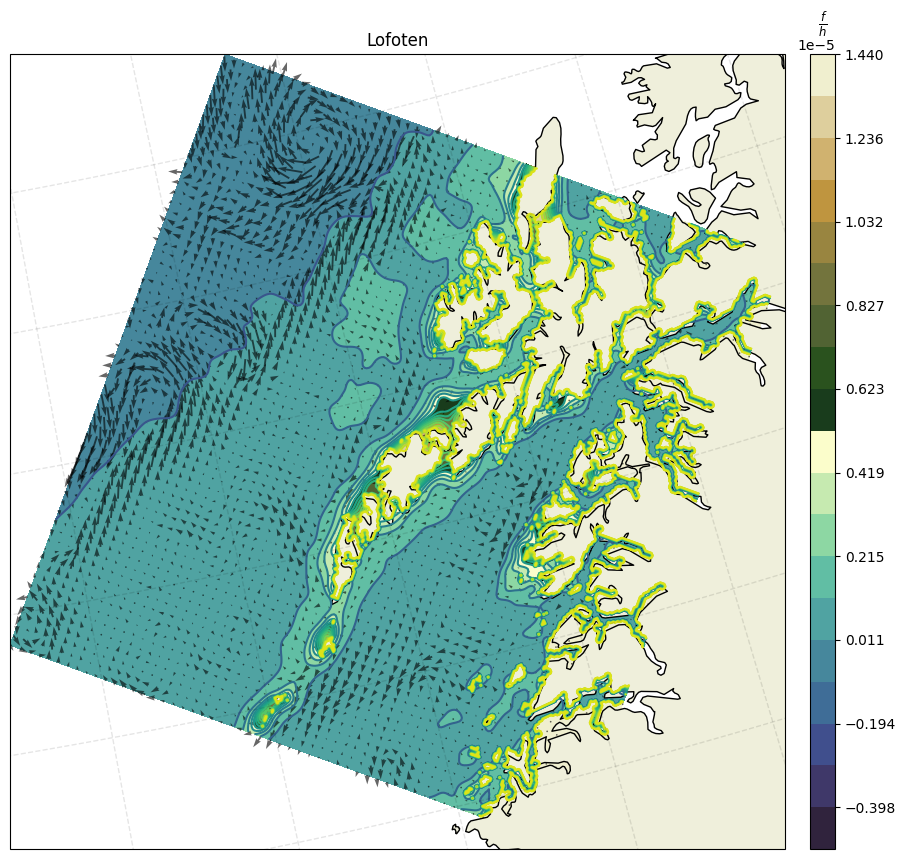

In [15]:
fig,ax = plt.subplots(figsize = (10,12), subplot_kw={'projection': ccrs.NorthPolarStereo()})
im = ax.contour(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
im2 = ax.contourf(Lofoten.longitude.values, Lofoten.latitude.values, f_h[0,:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
ax.quiver(Lofoten.longitude.values[::step, ::step], Lofoten.latitude.values[::step, ::step], mean_u_vel[0,:,:].values[::step, ::step], mean_v_vel[0,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 20)
cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
cbar = fig.colorbar(im2, ax=ax, cax = cax, extend = "both")
gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = False, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
gl.xlabels_top = False
ax.set_title('Lofoten')
cbar.ax.set_title(r'$\frac{f}{h}$')
ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')

In [16]:
from dataloader import open_dataset

In [17]:
ds_lof = open_dataset(file = f'{foccus}/{filepath}', region= 'lofoten').dataset

In [18]:
ds_lof

<xarray.Dataset> Size: 986MB
Dimensions:            (X: 747, Y: 805, time: 17)
Coordinates:
  * X                  (X) float64 6kB 2.488e+05 2.496e+05 ... 8.456e+05
  * Y                  (Y) float64 6kB 1.173e+06 1.174e+06 ... 1.816e+06
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 2MB nan nan nan nan ... nan nan nan nan
    longitude          (X, Y) float32 2MB nan nan nan nan ... nan nan nan nan
    h                  (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    salinity_0         (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    sea_mask           (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    temperature_0      (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    ...                 ...
    rain               (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    river_binary_mask  (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    sin_julian_day     (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    sin_latitude       (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    sin_local_time     (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan
    sin_longitude      (time, X, Y) float32 41MB nan nan nan nan ... nan nan nan

In [19]:
ds_sula = open_dataset(file = f'{foccus}/{filepath}', region= 'sulafjorden').dataset
ds_oslo = open_dataset(file = f'{foccus}/{filepath}', region= 'oslofjorden').dataset
#og et lengre uti for å se dynamikken et område med kun hav, feks ute ved kontinentalen
ds_sula

<xarray.Dataset> Size: 111MB
Dimensions:            (X: 289, Y: 235, time: 17)
Coordinates:
  * X                  (X) float64 2kB 4.488e+05 4.496e+05 ... 6.792e+05
  * Y                  (Y) float64 2kB 6.52e+05 6.528e+05 ... 8.392e+05
  * time               (time) datetime64[ns] 136B 2024-04-02 ... 2024-04-04
Data variables: (12/26)
    latitude           (X, Y) float32 272kB nan nan nan nan ... nan nan nan nan
    longitude          (X, Y) float32 272kB nan nan nan nan ... nan nan nan nan
    h                  (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    salinity_0         (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    sea_mask           (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    temperature_0      (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    ...                 ...
    rain               (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    river_binary_mask  (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    sin_julian_day     (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    sin_latitude       (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    sin_local_time     (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan
    sin_longitude      (time, X, Y) float32 5MB nan nan nan nan ... nan nan nan

In [20]:
ds_sula.head()

<xarray.Dataset> Size: 12kB
Dimensions:            (X: 5, Y: 5, time: 5)
Coordinates:
  * X                  (X) float64 40B 4.488e+05 4.496e+05 ... 4.52e+05
  * Y                  (Y) float64 40B 6.52e+05 6.528e+05 ... 6.552e+05
  * time               (time) datetime64[ns] 40B 2024-04-02 ... 2024-04-02T12...
Data variables: (12/26)
    latitude           (X, Y) float32 100B nan nan nan nan ... nan nan nan nan
    longitude          (X, Y) float32 100B nan nan nan nan ... nan nan nan nan
    h                  (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    salinity_0         (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    sea_mask           (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    temperature_0      (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    ...                 ...
    rain               (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    river_binary_mask  (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    sin_julian_day     (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    sin_latitude       (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    sin_local_time     (time, X, Y) float32 500B nan nan nan nan ... nan nan nan
    sin_longitude      (time, X, Y) float32 500B nan nan nan nan ... nan nan nan

In [96]:
def mean(ds):
    mean_u_vel = ds['u_eastward_0'].resample(time = '2D').mean(dim = 'time')
    mean_v_vel = ds['v_northward_0'].resample(time = '2D').mean(dim = 'time')
    return mean_u_vel, mean_v_vel

In [97]:
lofoten_u, lofoten_v = mean(ds_lof)
sula_u, sula_v = mean(ds_sula)
oslo_u, oslo_v = mean(ds_oslo)

In [127]:
import pyresample
#select an area
lon_min, lon_max = 11.83083, 15.59072
lat_min, lat_max = 67.41791, 69.20699


lon_ulc, lon_llc = 16.5, 16.5
lon_lrc, lon_urc = 23.4, 24.1
lat_urc, lat_ulc = 74.4, 74.4
lat_llc, lat_lrc = 73.1, 73.1

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid_n = pyresample.geometry.GridDefinition(lons=ds.longitude.values, lats = ds.latitude.values)
pos_geo_n = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid_n,
                                                    target_geo_def = pos_geo_n,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')

ds_ocean = ds.isel(Y=slice(y_min, y_max+1), X = slice(x_min, x_max +1))

X min: 783, X max: 1090
Y min: 2430, Y max: 2744


In [129]:
ds_ocean
ocean_u, ocean_v = mean(ds_ocean)

In [131]:
def calc_fh(ds):
    h = ds.h 
    f = ds.f 
    f_h = f.values / h.values 
    #check that it works
    print(f'f_h has dimensions: {f_h}')
    return f_h 

In [ ]:
calc_fh()

In [ ]:
plt.subplots(2,4, figsize = (14,12), subplot_kw={'projection' : ccrs.NorthPolarStereo()})
im = ax.contour(ds_lof.longitude.values, ds_lof.latitude.values, )